<div style="text-align:center; background:#2e2e2e; padding:32px 20px">
    <div style="font-size:46px; font-weight:bold; color:#f4f4ef; letter-spacing:4px; text-transform:uppercase">
        Sanghelios
    </div>
    <div style="font-size:17px; color:#888; margin-top:10px; letter-spacing:3px; text-transform:uppercase">
        Parte 1 — EDA y Preprocesamiento
    </div>
    <div style="font-size:17px; color:#666; margin-top:14px; letter-spacing:1px">
        Autores: Jose Miguel García Vélez & Jerónimo Hoyos Botero
    </div>
    <div style="font-size:17px; color:#666; margin-top:6px; letter-spacing:1px">
        Creado: Mayo 2025 &nbsp;|&nbsp; Última actualización: Junio 2026
    </div>
</div>

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Configuración
</div>

**Ajustes del notebooks**

In [220]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Importaciones**

In [221]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import missingno as msno

# Import zscore function
from scipy.stats import zscore
import numpy as np

# Utils
import math
import re
import unicodedata
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

from utils.functions import *

print("Funciones personalizadas cargadas correctamente")

Librerías cargadas correctamente
Funciones personalizadas cargadas correctamente


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Carga de Datos
</div>

In [222]:
paths = {
    "banco_sangre": r"..\data\raw\banco_sangre.csv",
    "defunciones": r"..\data\raw\defunciones.csv",
    "atenciones": r"..\data\raw\atenciones.csv",
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones = dataframes["defunciones"]
df_atenciones = dataframes["atenciones"]

print("\nDimensiones de los DataFrames:")
print("Banco de Sangre:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Atenciones:", df_atenciones.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\raw\banco_sangre.csv
'banco_sangre' loaded successfully. Shape: (35840, 11)
Loading data from: ..\data\raw\defunciones.csv
'defunciones' loaded successfully. Shape: (5094, 26)
Loading data from: ..\data\raw\atenciones.csv
'atenciones' loaded successfully. Shape: (221203, 12)

Dimensiones de los DataFrames:
Banco de Sangre:       (35840, 11)
Defunciones: (5094, 26)
Atenciones: (221203, 12)


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
Preparacion Dataframe del Banco de Sangre
</div>

Preprocesamiento del DataFrame de bancos de sangre y creacion de serie temporal donaciones por dia.

| | |
|---|---|
| **Autor** | Jerónimo Hoyos Botero |
| **Datos** | [banco_sangre.csv](https://github.com/Semillero-Inteligencia-Artificial-EAFIT/Sanghelios/blob/main/data/raw/banco_sangre.csv)|

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Vistazo de los datos
</div>

In [223]:
explorar_df(df_banco_sangre, "Banco de Sangre")


 Banco de Sangre  —  35,840 filas × 11 columnas
 Duplicados  1,622 (4.5%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
ANO,int64,,0,0.0,2020,2020,2020
TRIMESTRE,int64,,0,0.0,4,1,1
FECHA EXTRACCION,str,1335,0,0.0,28/12/2020,01/02/2020,01/02/2020
RH,str,8,41,0.1,0+,0+,0+
BARRIO,str,1274,7788,21.7,POPULAR 1,20 DE JULIO,20 DE JULIO
CIUDAD,str,28,0,0.0,MEDELLIN,MEDELLIN,MEDELLIN
EDAD,float64,,2,0.0,41.0,43.0,43.0
ESTATURA,float64,,79,0.2,NaN,1.74,1.74
FECHA NACIMIENTO,str,13393,2,0.0,1982 Jan 01 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Mar 12 12:00:00 AM
PESO,float64,,41,0.1,NaN,80.0,80.0


In [224]:
df_banco_sangre.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
ANO,2021.828599,1.569845,2020.0,2021.0,2022.00,2023.00,2025.00
TRIMESTRE,2.387249,1.118653,1.0,1.0,2.00,3.00,4.00
EDAD,37.713070,12.497798,14.0,27.0,36.00,47.00,104.00
ESTATURA,1.663522,0.089134,1.0,1.6,1.66,1.73,2.03
PESO,73.329004,13.517872,50.0,63.0,72.00,81.00,171.00


**Observaciones:**

- No se encontró variables con un >40% de datos nulos
- Se encontraron variables irrelevantes como "fecha nacimiento"
- Todas las variables categoricas contiene almenos 2 subniveles
- No se visualizan desviaciones estándar "muy bajas" dado el contexto de cada variable 
- Se encontraron 1622 filas duplicadas, equivalente a un 4.5% de todas las filas

Se realizará una estandarización de nombres de las variables y selección de columnas relevantes.

In [225]:
df_banco_sangre = estandarizar_columnas(df_banco_sangre)

  'ANO'                               → 'ano'
  'TRIMESTRE'                         → 'trimestre'
  'FECHA EXTRACCION'                  → 'fecha_extraccion'
  'RH'                                → 'rh'
  'BARRIO'                            → 'barrio'
  'CIUDAD'                            → 'ciudad'
  'EDAD'                              → 'edad'
  'ESTATURA'                          → 'estatura'
  'FECHA NACIMIENTO'                  → 'fecha_nacimiento'
  'PESO'                              → 'peso'
  'SEXO'                              → 'sexo'


In [226]:
columnas_originales_seleccionadas = [
    "fecha_extraccion",
    "rh",
    "barrio",
    "ciudad",
    "edad",
    "estatura",
    "peso",
    "sexo",
]

df_banco_sangre = df_banco_sangre[columnas_originales_seleccionadas]

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Tratamiento de filas repetidas
</div>

In [227]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df_banco_sangre.shape}')
df_banco_sangre.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df_banco_sangre.shape}')

Tamaño del set antes de eliminar las filas repetidas: (35840, 8)
Tamaño del set después de eliminar las filas repetidas: (34216, 8)


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Análisis Datos Faltantes
</div>

In [228]:
total = len(df_banco_sangre)
missing = df_banco_sangre.isna().sum()

pd.DataFrame({"Faltantes": missing, "%": (missing / total * 100).round(1)}).sort_values(
    "Faltantes", ascending=False
)

,Faltantes,%
barrio,7703,22.5
estatura,78,0.2
rh,41,0.1
peso,39,0.1
edad,2,0.0
sexo,1,0.0
ciudad,0,0.0
fecha_extraccion,0,0.0


<Axes: >

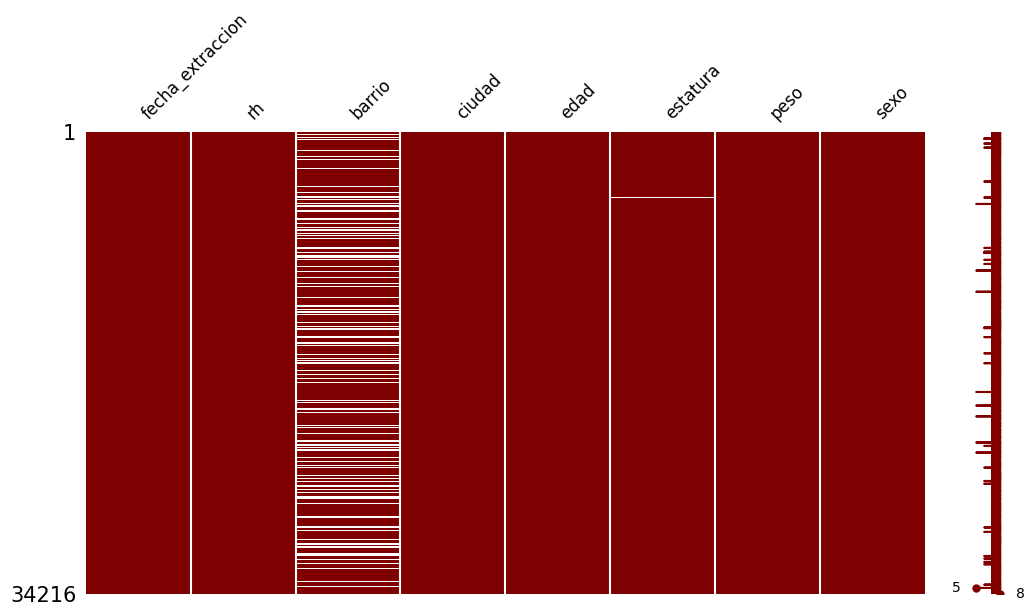

In [229]:
sorted_df = df_banco_sangre.sort_values("fecha_extraccion")
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

**Observaciones:**
- Las variables con datos faltantes tienen una proporción excluyendo la variable "barrio"
- La variable barrio tiene 7703, equivalente a un 22% de los datos.
- No se encontró un patrón claro del origen de los datos faltantes en "barrio"

> Se decide hacer una eliminación de todos los datos faltantes

In [230]:
print(f'Tamaño del set antes de eliminar las filas con valores faltantes: {df_banco_sangre.shape}')
df_banco_sangre = df_banco_sangre.dropna(subset=["rh", "estatura","barrio"])
print(f'Tamaño del set después de eliminar las filas con valores faltantes: {df_banco_sangre.shape}')

Tamaño del set antes de eliminar las filas con valores faltantes: (34216, 8)
Tamaño del set después de eliminar las filas con valores faltantes: (26412, 8)


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Análisis de Datos Atípicos
</div>

Los requisitos para donar sangre según la [Cruz Roja Colombiana](https://www.cruzrojacolombiana.org/banco-de-sangre/dona-sangre) son:
- Pesar más de 50 kg
- Edad entre 18 y 65 años

Por lo tanto se hace el filtrado

In [231]:
print(f'Tamaño del set antes del filtrado: {df_banco_sangre.shape}')
df_banco_sangre = df_banco_sangre[
    (df_banco_sangre["peso"] > 50)
    & (df_banco_sangre["edad"] >= 18)
    & (df_banco_sangre["edad"] <= 65)
]
print(f'Tamaño del set después del filtrado: {df_banco_sangre.shape}')

Tamaño del set antes del filtrado: (26412, 8)
Tamaño del set después del filtrado: (26267, 8)


Revisión de datos atipicos univariados

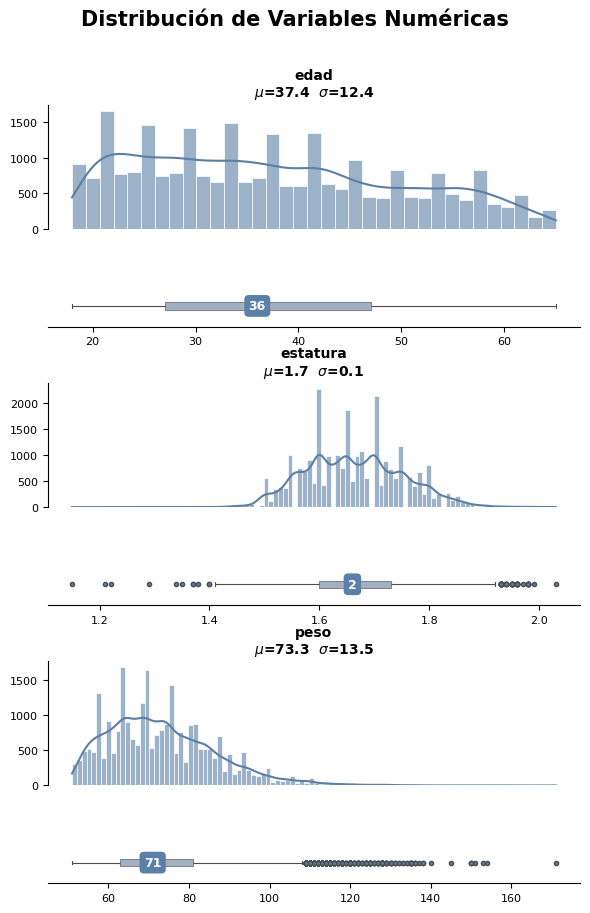

In [232]:
distribucion_numericas(df=df_banco_sangre, columnas=["edad", "estatura", "peso"],cols=1,modo="ambos",alto=3)

In [233]:
# IQR
print("\nIQR")
for col in ["edad", "peso", "estatura"]:
    Q1 = df_banco_sangre[col].quantile(0.25)
    Q3 = df_banco_sangre[col].quantile(0.75)
    IQR = Q3 - Q1
    n = (
        (df_banco_sangre[col] < Q1 - 1.5 * IQR)
        | (df_banco_sangre[col] > Q3 + 1.5 * IQR)
    ).sum()
    print(f"  {col}: {n} outliers")
    
# Z-score clásico
print("Z-score clásico")
for col in ["edad", "peso", "estatura"]:
    z = np.abs(zscore(df_banco_sangre[col].dropna()))
    print(f"  {col}: {(z > 3).sum()} outliers")

# Z-score modificado
print("\nZ-score modificado")
for col in ["edad", "peso", "estatura"]:
    mad = MAD(threshold=3.5)
    labels = mad.fit(df_banco_sangre[col].dropna().values.reshape(-1, 1)).labels_
    print(f"  {col}: {labels.sum()} outliers")


IQR
  edad: 0 outliers
  peso: 427 outliers
  estatura: 61 outliers
Z-score clásico
  edad: 0 outliers
  peso: 238 outliers
  estatura: 43 outliers

Z-score modificado
  edad: 0 outliers
  peso: 159 outliers
  estatura: 14 outliers


**Observaciones:**
- No se encontraron datos átipicos en la variable "edad" pero en "peso" y "estatura" sí se encontaron
- Se encuentra que "estatura" es bastante simetrica
- Se encuentra que "peso" con un sesgo negativo
> Se decide eliminar los datos atípicos de estatura con "Z-Score" y los "peso" con "Z-score modificado"

In [234]:
print(f'Tamaño del set antes de datos atípicos univariados: {df_banco_sangre.shape}')

z_edad = np.abs((df_banco_sangre["edad"] - df_banco_sangre["edad"].mean()) / df_banco_sangre["edad"].std())
outliers_edad = df_banco_sangre[z_edad > 3].index

peso_med = df_banco_sangre["peso"].median()
mad_peso = (df_banco_sangre["peso"] - peso_med).abs().median() or 1e-6
z_peso = (0.6745 * (df_banco_sangre["peso"] - peso_med).abs()) / mad_peso
outliers_peso = df_banco_sangre[z_peso > 3.5].index

df_banco_sangre = df_banco_sangre.drop(index=outliers_edad.union(outliers_peso))

print(f'Tamaño del set después de datos atípicos univariados: {df_banco_sangre.shape}')


Tamaño del set antes de datos atípicos univariados: (26267, 8)
Tamaño del set después de datos atípicos univariados: (26108, 8)


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de errores tipográficos en variables categóricos
</div>

**Ajuste de formatos**

In [235]:
df_banco_sangre.dtypes

fecha_extraccion        str
rh                      str
barrio                  str
ciudad                  str
edad                float64
estatura            float64
peso                float64
sexo                    str
dtype: object

In [236]:
# Aplicar un formato estandarizado a la fecha y convertir edad a entero

df_banco_sangre["fecha_extraccion"] = pd.to_datetime(df_banco_sangre["fecha_extraccion"], format="%d/%m/%Y").dt.date
df_banco_sangre["edad"] = df_banco_sangre["edad"].astype(int)

**Estandarización de variables categoricas**

In [237]:
# Define categorical columns to standardize labels
columnas_para_estandarizar = ["barrio", "ciudad", "sexo"]

# Apply standardization of categorical labels
for index in columnas_para_estandarizar:
    df_banco_sangre[index] = df_banco_sangre[index].apply(estandarizar_etiquetas)

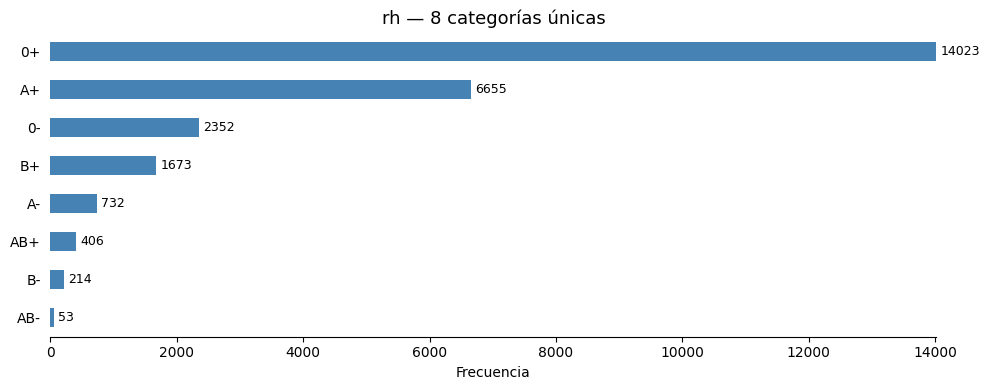

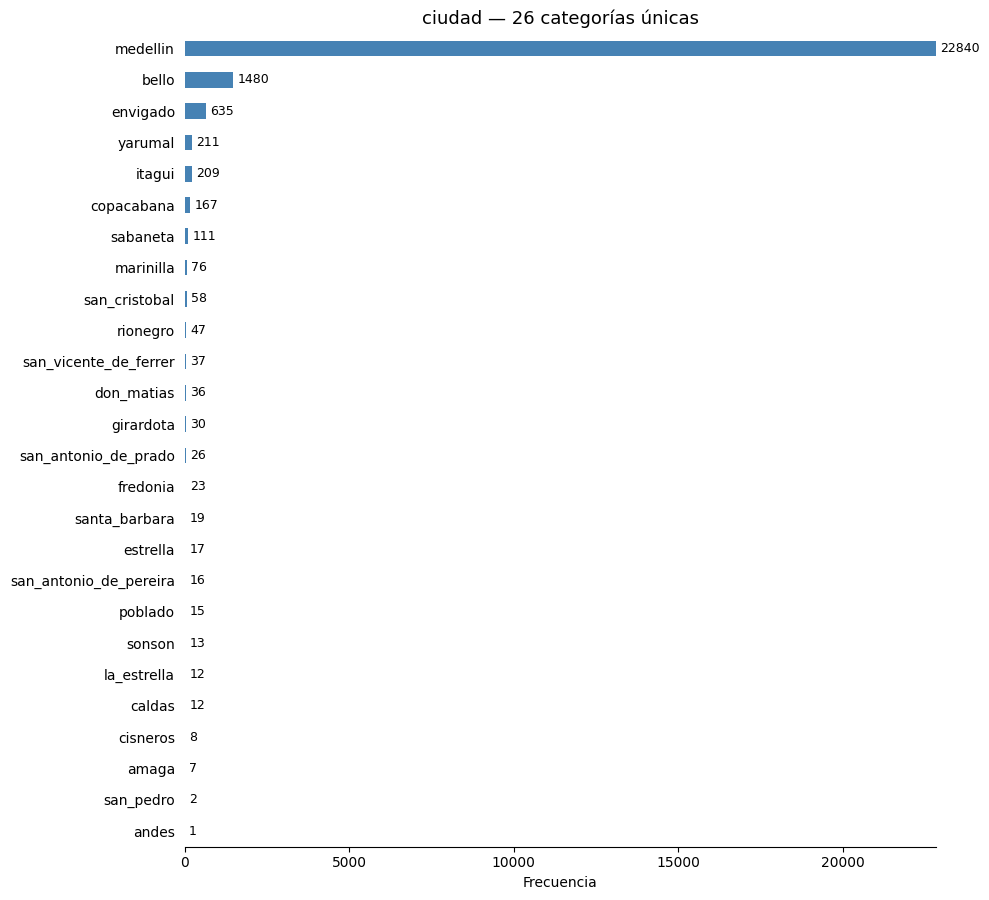

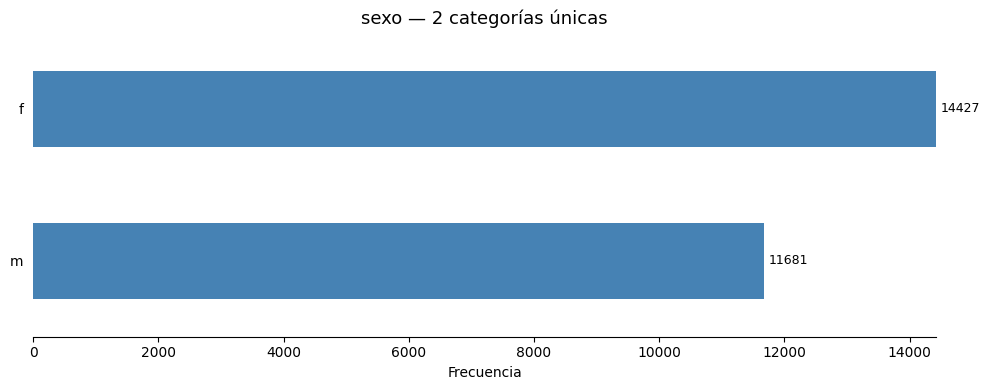

In [238]:
cols_cat = ["rh", "ciudad", "sexo"]

for col in cols_cat:
    conteo = df_banco_sangre[col].value_counts().sort_values(ascending=True)
    n = len(conteo)

    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.35)))
    conteo.plot(kind="barh", ax=ax, color="steelblue")

    ax.set_title(f"{col} — {n} categorías únicas", fontsize=13)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)

    ax.margins(0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)

    plt.tight_layout()
    plt.show()

**Observaciones**
- No se encontraron problemas tipograficos

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Ingeniería de Características 
</div>

Se creará la variable **cobertura**, que representa el porcentaje de la población que puede recibir sangre de un donante según su tipo sanguíneo y las reglas de compatibilidad ABO/Rh. Los porcentajes de distribución poblacional provienen del estudio [Ramírez-González et al. (2014)](https://dialnet.unirioja.es/descarga/articulo/8741610.pdf), realizado con 87.481 donantes del Hospital Pablo Tobón Uribe de Medellín entre 2000 y 2009.

In [239]:
# Distribución poblacional colombiana
dist_poblacion = {
    "0+": 52.1,
    "A+": 28.0,
    "B+": 7.0,
    "0-": 6.7,
    "A-": 3.5,
    "B-": 1.7,
    "AB+": 0.8,
    "AB-": 0.3,
}

# Cobertura: % de población que puede recibir cada tipo
cobertura_map = {
    "0-": 100.0,  # ← dona a todos, simplemente es 100%
    "0+": sum([dist_poblacion[k] for k in ["0+", "A+", "B+", "AB+"]]),
    "A-": sum([dist_poblacion[k] for k in ["A+", "A-", "AB+", "AB-"]]),
    "A+": sum([dist_poblacion[k] for k in ["A+", "AB+"]]),
    "B-": sum([dist_poblacion[k] for k in ["B+", "B-", "AB+", "AB-"]]),
    "B+": sum([dist_poblacion[k] for k in ["B+", "AB+"]]),
    "AB-": sum([dist_poblacion[k] for k in ["AB+", "AB-"]]),
    "AB+": sum([dist_poblacion[k] for k in ["AB+"]]),
}

# Agregamos ambas columnas al DataFrame basándonos en el 'rh'
df_banco_sangre["cobertura"] = df_banco_sangre["rh"].map(cobertura_map)
df_banco_sangre["pct_poblacion"] = df_banco_sangre["rh"].map(dist_poblacion)

# Agrupamos para obtener los valores únicos por cada RH presente en tu DataFrame
resultado = (
    df_banco_sangre.groupby("rh")[["pct_poblacion", "cobertura"]]
    .first()
    .sort_values("pct_poblacion", ascending=False)
)

print(f"{'RH':<5} | {'% Población Col.':<16} | {'% Cobertura':<26}")
print("-" * 55)
for sangre, filas in resultado.iterrows():
    print(
        f"{sangre:<5} | {filas['pct_poblacion']:>14.1f}% | {filas['cobertura']:>23.1f}%"
    )

RH    | % Población Col. | % Cobertura               
-------------------------------------------------------
0+    |           52.1% |                    87.9%
A+    |           28.0% |                    28.8%
B+    |            7.0% |                     7.8%
0-    |            6.7% |                   100.0%
A-    |            3.5% |                    32.6%
B-    |            1.7% |                     9.8%
AB+   |            0.8% |                     0.8%
AB-   |            0.3% |                     1.1%


Se creará la variable **imc** a partir del peso y la estatura del donante, reemplazando ambas variables por un único indicador clínico.

In [240]:
# Calcular IMC
df_banco_sangre["imc"] = (
    df_banco_sangre["peso"] / (df_banco_sangre["estatura"] ** 2)
).round(2)

# Eliminar estatura
df_banco_sangre = df_banco_sangre.drop(columns=["estatura", "peso"])

Se creará la variable **comuna** únicamente para los donantes de Medellín, asignando **no_aplica** al resto de municipios dado que no comparten el mismo esquema de división territorial.


In [241]:
from utils.barrios import *

df_banco_sangre["comuna_o_municipio"] = df_banco_sangre["barrio"].apply(get_comuna)
df_banco_sangre["comuna_o_municipio"].value_counts()

comuna_o_municipio
Bello                        3125
16 - Belén                   2069
7 - Robledo                  1843
Envigado                     1619
Itagüí                       1455
14 - El Poblado              1454
11 - Laureles-Estadio        1290
12 - La América              1109
9 - Buenos Aires             1087
3 - Manrique                 1073
5 - Castilla                 1040
4 - Aranjuez                  917
13 - San Javier               894
10 - La Candelaria            720
6 - Doce de Octubre           716
8 - Villa Hermosa             699
2 - Santa Cruz                661
1 - Popular                   586
15 - Guayabal                 521
desconocido                   440
Sabaneta                      424
60 - San Cristóbal            384
Caldas                        368
80 - San Antonio de Prado     327
Copacabana                    292
La Estrella                   243
90 - Santa Elena              230
70 - Altavista                223
Yarumal                      

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Resultado Limpieza
</div>

In [242]:
explorar_df(df_banco_sangre, "Banco de Sangre")


 Banco de Sangre  —  26,108 filas × 10 columnas
 Duplicados  0 (0.0%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
fecha_extraccion,object,1321,0,0.0,2020-02-01,2020-02-01,2020-02-01
rh,str,8,0,0.0,0+,0+,0-
barrio,str,1268,0,0.0,20_de_julio,20_de_julio,cataluna
ciudad,str,26,0,0.0,medellin,medellin,medellin
edad,int64,,0,0.0,43,44,58
sexo,str,2,0,0.0,m,f,f
cobertura,float64,,0,0.0,87.9,87.9,100.0
pct_poblacion,float64,,0,0.0,52.1,52.1,6.7
imc,float64,,0,0.0,26.42,33.59,29.39
comuna_o_municipio,str,45,0,0.0,13 - San Javier,13 - San Javier,9 - Buenos Aires


In [243]:
df_banco_sangre.to_csv("../data/processed/df_banco_sangre_preprocessed.csv", index=True)

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
Preparacion Dataframe de Atenciones
</div>


Preprocesamiento del DataFrame de atenciones y creacion de serie temporal atenciones por dia.

| | |
|---|---|
| **Responsable** | Jose Miguel García Vélez |
| **Datos** | [atenciones.csv](https://github.com/Semillero-Inteligencia-Artificial-EAFIT/Sanghelios/blob/main/data/raw/atenciones.csv)|
| **Período** | 2022 – 2025 |

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Información inicial del DataFrame
</div>

In [244]:
explorar_df(df_atenciones,"Atenciones")


 Atenciones  —  221,203 filas × 12 columnas
 Duplicados  9,626 (4.4%)


,dtype,subniveles,nulos,% nulos,ej 1,ej 2,ej 3
AÑO,int64,,0,0.0,2022,2022,2022
Periodo de reporte,int64,,0,0.0,1,1,1
Fecha atencion,str,1274,0,0.0,02/01/2022,02/01/2022,02/01/2022
servicio,str,4,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio
Sexo,str,3,5,0.0,M,M,M
Cod. Aseguradora,float64,,4972,2.2,20002686.0,20000362.0,20000368.0
Aseguradora,str,285,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA
Poblacion,str,6481,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ
Departamento,str,33,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,,0,0.0,2,35,24


In [245]:
# Estandarizar nombres de columnas: eliminar espacios y convertir a minúsculas
df_atenciones.columns = (
    df_atenciones.columns.str.strip().str.lower().str.replace(" ", "_")
)
print("\nColumnas estandarizadas:")
print(df_atenciones.columns.tolist())


Columnas estandarizadas:
['año', 'periodo_de_reporte', 'fecha_atencion', 'servicio', 'sexo', 'cod._aseguradora', 'aseguradora', 'poblacion', 'departamento', 'edad', 'rango_de_edad', 'regimen']


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Tipado
</div>

In [246]:
# Fecha de atencion: convertir a datetime
df_atenciones["fecha_atencion"] = pd.to_datetime(
    df_atenciones["fecha_atencion"].astype("string"), errors="coerce"
)

# Rango de fechas
fecha_min = df_atenciones["fecha_atencion"].min()
fecha_max = df_atenciones["fecha_atencion"].max()
print(f"\nRango de fechas en 'fecha_atencion': {fecha_min.date()} a {fecha_max.date()}")


Rango de fechas en 'fecha_atencion': 2022-01-02 a 2026-12-03


In [247]:
# Codigo asegurado: convertir a string (sin .0)
df_atenciones = df_atenciones.astype({"cod._aseguradora": "string"})
df_atenciones["cod._aseguradora"] = df_atenciones["cod._aseguradora"].str.replace(
    ".0", "", regex=False
)

# Ejemplo de valores unicos en 'Cod. Aseguradora'
print("\nEjemplo de valores unicos en 'Cod. Aseguradora':")
print(df_atenciones["cod._aseguradora"].unique()[:10])


Ejemplo de valores unicos en 'Cod. Aseguradora':
<StringArray>
['20002686', '20000362', '20000368', '20000366', '20000465', '20002569',
 '20003122', '20000348', '20002687', '20002818']
Length: 10, dtype: string


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Estandarización de strings
</div>

In [248]:
# servicio → uppercase
df_atenciones["servicio"] = df_atenciones["servicio"].str.upper()

# Departamento → sin tildes, normalizado
df_atenciones["departamento"] = (
    df_atenciones["departamento"]
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

# rango de edad → unificar ≥65
df_atenciones["rango_de_edad"] = df_atenciones["rango_de_edad"].replace(
    {">= 65 AÑOS": "≥65 AÑOS"}
)

# regimen → OTRO / OTROS → OTRO
df_atenciones["regimen"] = df_atenciones["regimen"].replace(
    {"OTRO": "OTRO", "OTROS": "OTRO"}
)

# Sexo = 'I' → NaN
df_atenciones["sexo"] = df_atenciones["sexo"].replace({"I": np.nan})

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Variable Población
</div>

In [249]:
def separar_poblacion(valor):
    """
    Separa la columna Poblacion en (barrio, comuna) según el patrón detectado.

    Patrones:
      - 'barrio  COMUNA'        → (barrio, COMUNA)   [doble espacio como separador]
      - 'MUNICIPIO MUNICIPIO'   → (NaN, MUNICIPIO)   [repetición = sin barrio]
      - 'NombreSolo'            → (NombreSolo, NaN)  [solo barrio / ambiguo]
      - Triple estructura       → tomar primeras dos partes
      - NaN                     → (NaN, NaN)
    """
    if pd.isna(valor):
        return pd.NA, pd.NA

    # Normalizar 3+ espacios consecutivos a doble espacio
    valor = re.sub(r"   +", "  ", valor.strip())

    # ── Caso 1: tiene doble espacio → separar ─────────────────────────────
    partes = re.split(r"  ", valor)
    if len(partes) >= 2:
        barrio = partes[0].strip() or pd.NA
        comuna = partes[1].strip() or pd.NA
        return barrio, comuna

    # ── Caso 2: espacio simple → detectar patrón MUNICIPIO MUNICIPIO ──────
    nombre = valor.strip()
    tokens = nombre.split()
    mitad = len(tokens) // 2

    if len(tokens) >= 2 and len(tokens) % 2 == 0:
        primera = " ".join(tokens[:mitad]).upper()
        segunda = " ".join(tokens[mitad:]).upper()
        if primera == segunda:
            return pd.NA, primera  # municipio sin barrio

    # ── Caso 3: solo nombre → barrio ──────────────────────────────────────
    return nombre, pd.NA


# Aplicar al dataset
result = df_atenciones["poblacion"].apply(separar_poblacion)
df_atenciones["poblacion_barrio"] = result.apply(lambda x: x[0])
df_atenciones["poblacion_comuna"] = result.apply(lambda x: x[1])

# Corregir typo conocido en comuna
df_atenciones["poblacion_comuna"] = df_atenciones["poblacion_comuna"].replace(
    {"CASTILLLA": "CASTILLA"}
)

# Eliminar columna original
df_atenciones = df_atenciones.drop(columns=["poblacion"])

# ── Reporte ───────────────────────────────────────────────────────────────
print("Cobertura de poblacion_barrio:")
print(f"  No-nulo: {df_atenciones['poblacion_barrio'].notna().sum():,}")
print(
    f"  Nulo:    {df_atenciones['poblacion_barrio'].isna().sum():,}  "
    f"({df_atenciones['poblacion_barrio'].isna().mean()*100:.1f}%)"
)
print()
print("Cobertura de poblacion_comuna:")
print(f"  No-nulo: {df_atenciones['poblacion_comuna'].notna().sum():,}")
print(
    f"  Nulo:    {df_atenciones['poblacion_comuna'].isna().sum():,}  "
    f"({df_atenciones['poblacion_comuna'].isna().mean()*100:.1f}%)"
)
print()
print("Top 10 barrios:")
print(df_atenciones["poblacion_barrio"].value_counts().head(10))
print()
print("Top 10 comunas:")
print(df_atenciones["poblacion_comuna"].value_counts().head(10))

Cobertura de poblacion_barrio:
  No-nulo: 138,312
  Nulo:    82,891  (37.5%)

Cobertura de poblacion_comuna:
  No-nulo: 94,946
  Nulo:    126,257  (57.1%)

Top 10 barrios:
poblacion_barrio
BELLO            8651
Robledo          4492
Buenos Aires     3300
Villa Hermosa    2797
ITAGUI           2754
Manrique         2547
Popular          2443
Castilla         2166
Aranjuez         1989
Enciso           1467
Name: count, dtype: int64

Top 10 comunas:
poblacion_comuna
BELLO            11587
ROBLEDO           5136
BUENOS AIRES      4775
MANRIQUE          4362
ITAGUI            3917
POPULAR           2864
VILLA HERMOSA     2782
ARANJUEZ          2405
CASTILLA          1984
COPACABANA        1922
Name: count, dtype: int64


Documentación de nulos

Los **57,998 nulos (26.2%)** en `poblacion` son **estructurales**: corresponden a pacientes
atendidos en el HGM que residen fuera de Medellín (otros municipios o departamentos).
Su residencia ya queda capturada en `departamento`. Se conservan como `NaN` en ambas
columnas derivadas — **no se imputan**.

> La columna original `poblacion` se elimina tras la separación.

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Outliers
</div>

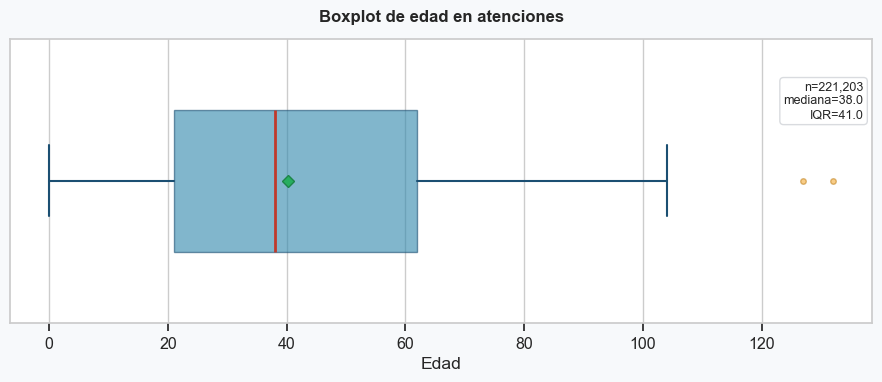

In [250]:
# Boxplot edad (estandarizado)
set_plot_style()
boxplot_pro(df_atenciones["edad"], title="Boxplot de edad en atenciones", xlabel="Edad")

In [251]:
# Ver edades mayores a 120 años
print("\nAtenciones con edad > 120 años:")
print(df_atenciones[df_atenciones["edad"] > 120][["edad", "fecha_atencion"]])

# La edad mas alta registrada en la historia es de 122 años, por lo que estos datos atipicos podrían ser errores de digitación o registros incorrectos. Procedemos a elimirlos.

df_atenciones = df_atenciones[df_atenciones["edad"] <= 120]

# Rango de edades
print("\nRango de edades en atenciones:")
print(f"Edad mínima: {df_atenciones['edad'].min()}")
print(f"Edad máxima: {df_atenciones['edad'].max()}")


Atenciones con edad > 120 años:
        edad fecha_atencion
201987   132            NaT
212636   127     2026-10-03

Rango de edades en atenciones:
Edad mínima: 0
Edad máxima: 104


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Cortar rango fechas para serie de tiempo
</div>

In [252]:
# Definir fechas hasta 2025-06-27
fecha_limite = pd.to_datetime("2025-06-27")
df_2 = df_atenciones.loc[df_atenciones["fecha_atencion"] <= fecha_limite].copy()

# Rango de fechas en 'fecha_atencion' después de filtrar
fecha_min_2 = df_2["fecha_atencion"].min()
fecha_max_2 = df_2["fecha_atencion"].max()
print(
    f"\nRango de fechas en 'fecha_atencion' después de filtrar: {fecha_min_2.date()} a {fecha_max_2.date()}"
)


Rango de fechas en 'fecha_atencion' después de filtrar: 2022-01-02 a 2025-06-12


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Atenciones por dia serie de timpo
</div>

In [253]:
# Numero de atenciones por dia
atenciones_por_dia = df_2.groupby("fecha_atencion").size()
print("\nNúmero de atenciones por día (primeros 10 días):")
print(atenciones_por_dia.head(3))

# Crear columna con el número de atenciones por día
df_2.loc[:, "atenciones_por_dia"] = df_2["fecha_atencion"].map(atenciones_por_dia)
print("\nEjemplo de filas con la nueva columna 'atenciones_por_dia':")
display(df_2[["fecha_atencion", "atenciones_por_dia"]].head(3))

# compararar atenciones_por_dia y la nueva columna 'atenciones_por_dia' para verificar que coinciden
comparacion = df_2["atenciones_por_dia"] == df_2["fecha_atencion"].map(
    atenciones_por_dia
)
print(f"\n¿Las columnas 'atenciones_por_dia' y el mapeo coinciden? {comparacion.all()}")


Número de atenciones por día (primeros 10 días):
fecha_atencion
2022-01-02    223
2022-01-03    242
2022-01-04    264
dtype: int64

Ejemplo de filas con la nueva columna 'atenciones_por_dia':


,fecha_atencion,atenciones_por_dia
0,2022-02-01,44
1,2022-02-01,44
2,2022-02-01,44



¿Las columnas 'atenciones_por_dia' y el mapeo coinciden? True


In [254]:
# Convertir tabla en un DataFrame
atenciones_por_dia = (
    df_2.groupby("fecha_atencion").size().reset_index(name="atenciones_por_dia")
)
display(atenciones_por_dia.head(10))

# Cambiar nombre y exportar a csv
atenciones_por_dia.to_csv("../data/processed/df_atenciones_time_series.csv", index=True)

,fecha_atencion,atenciones_por_dia
0,2022-01-02,223
1,2022-01-03,242
2,2022-01-04,264
3,2022-01-05,70
4,2022-01-06,573
5,2022-01-07,401
6,2022-01-08,413
7,2022-01-09,349
8,2022-01-10,45
9,2022-01-11,306


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Exportar datos para EDA
</div>

In [255]:
atenciones_processed = df_atenciones.copy()
atenciones_processed.to_csv(
    "../data/processed/df_atenciones_processed.csv", index=False
)